TEST INFERENCE PIPELINE (Toy Model)
Model: ../checkpoints/clip_medium.pth
Test set: ../data/val/eurecom/images
Loading openai/clip-vit-base-patch16...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Backbone frozen (only classifier trainable)
✓ Parameters: 197,121 trainable / 149,817,858 total
✓ Model loaded: ../checkpoints/clip_medium.pth
  Validation AUC: 0.9457
Loaded 2000 test images


Predicting:   0%|          | 0/125 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>
  data = fetch_version_info()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>
  data = fetch_version_info()
Predicting: 100%|██████████| 125/125 [01:42<00:00,  1.22it/s]


✓ Predictions saved: ../submissions/medium_predictions.csv

Prediction Statistics:
  Total images: 2000
  Mean prediction: 0.4445
  Std prediction: 0.2950
  Min: 0.0038 | Max: 0.9993
  Predicted Fake (>0.5): 836 (41.8%)
  Predicted Real (≤0.5): 1164 (58.2%)

PREDICTION DISTRIBUTION


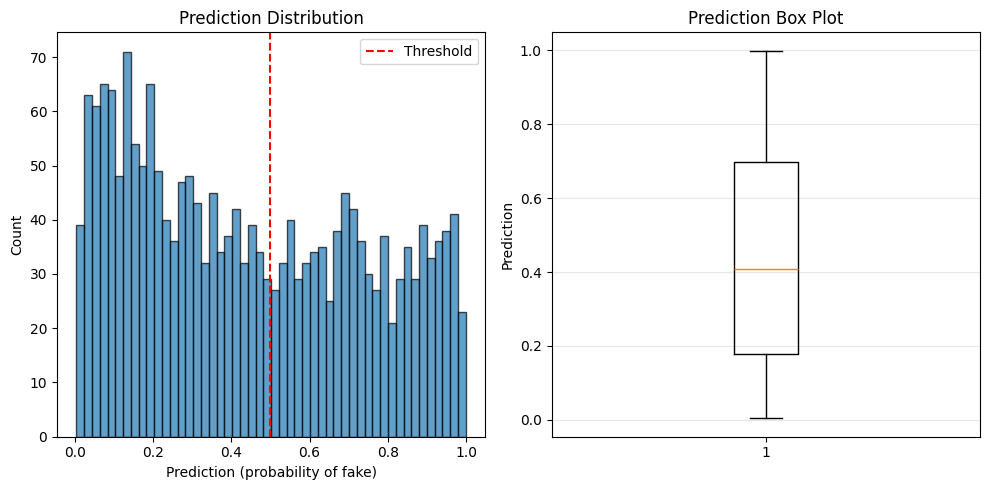


⚠️  Remember: This is a TOY model (trained on 800 samples)
Results are NOT meaningful, just testing the pipeline!


In [ ]:
# ========================================
# Test Inference Pipeline
# ========================================

import sys
sys.path.append('../')
import os
import matplotlib.pyplot as plt

from src.inference import predict

# Create submissions dir
os.makedirs('../submissions', exist_ok=True)

# Config
MODEL_PATH = '../checkpoints/clip_medium.pth'
TEST_DIR = '../data/val/eurecom/images'
OUTPUT_CSV = '../submissions/medium_predictions.csv'

print("=" * 60)
print("TEST INFERENCE PIPELINE (Toy Model)")
print("=" * 60)
print(f"Model: {MODEL_PATH}")
print(f"Test set: {TEST_DIR}")
print("=" * 60)

# Generate predictions
df = predict(
    model_path=MODEL_PATH,
    test_images_dir=TEST_DIR,
    output_csv=OUTPUT_CSV,
    device='mps',
    batch_size=16
)

# Visualize distribution
print("\n" + "=" * 60)
print("PREDICTION DISTRIBUTION")
print("=" * 60)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(df['label'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Prediction (probability of fake)')
plt.ylabel('Count')
plt.title('Prediction Distribution')
plt.axvline(x=0.5, color='r', linestyle='--', label='Threshold')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df['label'])
plt.ylabel('Prediction')
plt.title('Prediction Box Plot')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
